In [29]:
import pandas as pd
import numpy as np
from autogluon.tabular import TabularPredictor
import seaborn as sns
from sdv.metadata import Metadata
from sdv.single_table import CTGANSynthesizer

np.random.seed(29)

In [2]:
odroid1 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid1_firefox_onscreen.csv")
odroid2 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid2_firefox_onscreen.csv")
odroid3 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid3_firefox_onscreen.csv")
odroid4 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid4_firefox_onscreen.csv")

In [3]:
rpi4a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-4a_chrome_onscreen.csv")
rpi8a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8a_chrome_onscreen.csv")
rpi8b = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8b_chrome_onscreen.csv")
rpi8c = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8c_chrome_onscreen.csv")
rpi8d = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8d_chrome_onscreen.csv")

In [36]:
df = pd.concat([odroid1[:2000], odroid2[:2000], odroid3[:2000], odroid4[:2000], rpi4a[:2000], rpi8a[:2000], rpi8b[:2000], rpi8c[:2000], rpi8d[:2000]])
df = df.sample(frac=1, random_state=29).reset_index(drop=True)

In [37]:
len(df)

18000

In [38]:
model_hardening_data = df.head(6000)
intercepted_data = df.tail(12000)

In [39]:
model_hardening_data

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
0,odroid2,186.0,10.0,150.0,350.0,167.0,167.0,166.0
1,rpi-4a,16.2,17.4,1446.0,17.8,435.5,17.1,19.3
2,odroid1,165.0,167.0,167.0,168.0,169.0,166.0,168.0
3,odroid4,169.0,175.0,176.0,174.0,174.0,173.0,173.0
4,rpi-8c,24.9,629.1,16.7,2092.1,16.1,17.3,17.6
...,...,...,...,...,...,...,...,...
5995,odroid1,166.0,170.0,167.0,169.0,166.0,168.0,168.0
5996,odroid2,180.0,172.0,156.0,172.0,170.0,12.0,166.0
5997,odroid4,170.0,175.0,175.0,173.0,174.0,175.0,173.0
5998,rpi-4a,620.7,400.1,19.8,18.2,21.0,18.9,19.9


In [40]:
intercepted_data

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
6000,odroid4,173.0,172.0,174.0,174.0,171.0,172.0,173.0
6001,odroid3,165.0,167.0,168.0,166.0,167.0,167.0,164.0
6002,odroid4,170.0,174.0,173.0,173.0,174.0,173.0,171.0
6003,rpi-8d,16.1,17.8,17.4,781.8,17.6,19.1,19.1
6004,odroid4,172.0,173.0,175.0,174.0,174.0,174.0,175.0
...,...,...,...,...,...,...,...,...
17995,rpi-8a,230.7,231.9,433.3,16.6,232.2,233.2,433.4
17996,odroid1,166.0,169.0,168.0,167.0,168.0,167.0,169.0
17997,odroid1,329.0,169.0,168.0,168.0,167.0,167.0,168.0
17998,rpi-8a,416.6,229.9,16.2,216.5,416.5,233.2,433.5


In [41]:
predictor = TabularPredictor.load("../models/classification")

In [42]:
metadata = Metadata.detect_from_dataframe(
    data=intercepted_data,
    table_name='intercepted_data')

# Which epoch performs the best?

### This takes a very long time (2hrs with an RTX A5000), make sure you have a GPU or adjust epoch interals

In [43]:
vae_results = pd.DataFrame(columns=['epoch', 'accuracy', 'balanced_accuracy', 'mcc'])

for i in range(100,2000,100):
    print(i)
    synthesizer = CTGANSynthesizer(
        metadata, 
        epochs=i
    )
    
    synthesizer.fit(intercepted_data)
    synthetic_data = synthesizer.sample(num_rows=1000)
    
    y_pred = predictor.predict(synthetic_data)
    y_pred_proba = predictor.predict_proba(synthetic_data)
    results = predictor.evaluate(synthetic_data)
    
    new_results = {'epoch':i, 'accuracy':results['accuracy'], 'balanced_accuracy':results['balanced_accuracy'], 'mcc':results['mcc']}
    vae_results.loc[len(vae_results)] = (new_results)

100


c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\sdv\single_table\base.py:104: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.



200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900


# Epoch 1000 is able to fool our classification model most often

<Axes: xlabel='epoch', ylabel='value'>

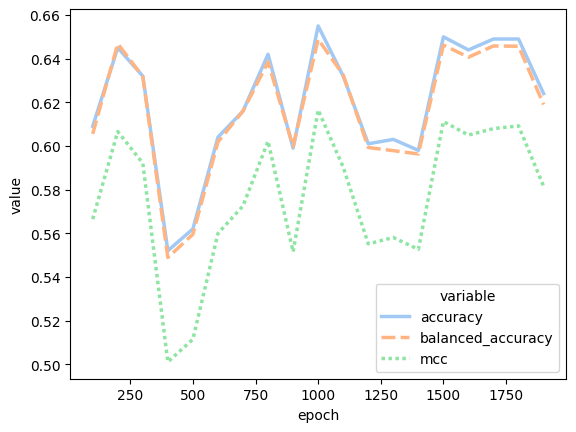

In [44]:
sns.lineplot(data=pd.melt(vae_results, ['epoch']), x='epoch', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)

In [56]:
synthesizer = CTGANSynthesizer(
    metadata, 
    epochs=1000
)

synthesizer.fit(intercepted_data)
synthetic_impersonation_data = synthesizer.sample(num_rows=1000)

In [64]:
synthetic_impersonation_data.to_csv('synthetic_gan_impersonator.csv')

## Which devices are most vulnerable to this attack?

In [46]:
devices_fooled = pd.DataFrame(columns=['device', 'accuracy'])
for device in list(y_pred.unique()):
    devices_fooled.loc[len(devices_fooled)] = {'device': device, 'accuracy': 0.0}

for pred, label in zip(list(y_pred), list(synthetic_impersonation_data['label'])):
    if pred == label:
        devices_fooled.loc[devices_fooled['device'] == pred, 'accuracy'] += 1

for device in list(y_pred.unique()):
    devices_fooled.loc[devices_fooled['device'] == device, 'accuracy'] /= list(synthetic_impersonation_data['label']).count(device)

devices_fooled['accuracy'] *= 100

<Axes: xlabel='device', ylabel='accuracy'>

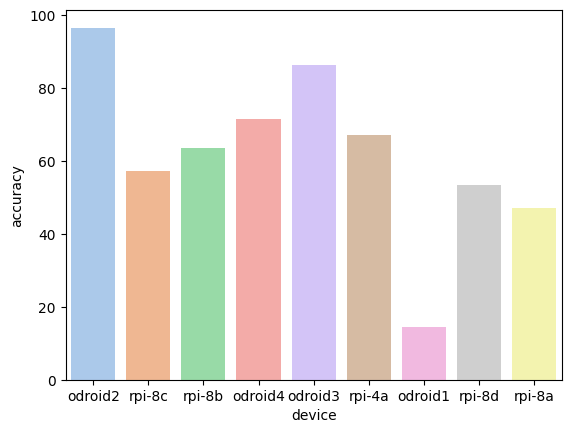

In [47]:
sns.barplot(data=devices_fooled, x='device', y='accuracy', hue='device', palette="pastel", legend=False, linewidth=2.5)

# Training an impersonation detection model

### How much adversarial training data do we need to accurately detect an impersonation attack?

In [48]:
# Let's say we use the same epoch as our adversary, and assume it's also the best epoch for our smaller dataset.
# However, we train the synthesizer on our train data ONLY.
# train and test data are used to train separate synthesizer models.
epoch = 1000

synthesizer = CTGANSynthesizer(
    metadata, 
    epochs=epoch
)

# Train the synthetic model using 75% of a train data. Holdout the rest for eval
synthesizer.fit(model_hardening_data.head(4500))

In [60]:
results_df = pd.DataFrame(columns=['data_amount', 'accuracy', 'balanced_accuracy', 'mcc'])

# How much data do we need to accurately detect an impersonator?
for synthetic_data_amount in range(100, 1000, 100):
    print(f'Amount of data: {synthetic_data_amount}')

    impersonator_df = synthesizer.sample(num_rows=synthetic_data_amount)
    impersonator_df['label'] = 'impersonator'

    genuine_df = model_hardening_data[:4500].copy()
    genuine_df['label'] = 'genuine'

    genuine_and_impersonator_df = pd.concat([impersonator_df, genuine_df])

    impersonation_detector = TabularPredictor(label='label').fit(genuine_and_impersonator_df, num_gpus=1, presets='medium_quality', fit_weighted_ensemble=False)

    # Create an eval dataset for the impersonation detector.
    # Use the held out data from the train_set (reserved for model hardening), and some data from the test_set (reserved to simulate an attack)
    test_model_hardening = model_hardening_data.tail(1500).copy(deep=True)
    test_intercepted_data = synthetic_impersonation_data.copy(deep=True)
    test_model_hardening['label'] = 'genuine'
    test_intercepted_data['label'] = 'impersonator'

    test_impersonator_df = pd.concat([test_model_hardening, test_intercepted_data])
    
    y_pred = impersonation_detector.predict(test_impersonator_df)
    y_pred_proba = impersonation_detector.predict_proba(test_impersonator_df)
    results = impersonation_detector.evaluate(test_impersonator_df)

    print(results)

    new_results = {'data_amount':synthetic_data_amount, 'accuracy':results['accuracy'], 'balanced_accuracy':results['balanced_accuracy'], 'mcc':results['mcc']}
    results_df.loc[len(results_df)] = (new_results)

No path specified. Models will be saved in: "AutogluonModels\ag-20250325_074017"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.11.11
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          32
Memory Avail:       48.55 GB / 63.72 GB (76.2%)
Disk Space Avail:   921.73 GB / 1906.98 GB (48.3%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 2 - Spoofing Attack Detection\AutogluonModels\ag-20250325_074017"
Train Data Rows:    6100
Train Data Columns: 7
Label Column:       label
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  ['impersonator', 'genuine']
	If 'binary' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may

Amount of data: 100


	0.9852	 = Validation score   (accuracy)
	2.27s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.9885	 = Validation score   (accuracy)
	1.57s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.9852	 = Validation score   (accuracy)
	0.39s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.9852	 = Validation score   (accuracy)
	0.36s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.9836	 = Validation score   (accurac

{'accuracy': 0.6712, 'balanced_accuracy': np.float64(0.5891666666666666), 'mcc': np.float64(0.3379853777622611), 'roc_auc': np.float64(0.8981306666666667), 'f1': np.float64(0.30338983050847457), 'precision': np.float64(0.9944444444444445), 'recall': np.float64(0.179)}
Amount of data: 200


	0.9742	 = Validation score   (accuracy)
	2.87s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.9855	 = Validation score   (accuracy)
	3.13s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.9758	 = Validation score   (accuracy)
	0.4s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.9758	 = Validation score   (accuracy)
	0.36s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.9742	 = Validation score   (accuracy

...

[1000]	valid_set's binary_error: 0.0338235


	0.9691	 = Validation score   (accuracy)
	6.08s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.9471	 = Validation score   (accuracy)
	0.41s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.9515	 = Validation score   (accuracy)
	0.38s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.9412	 = Validation score   (accuracy)
	0.35s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: ExtraTreesEntr ...
	0.9412	 = Validation score   (accuracy)
	0.34s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: NeuralNetFastAI ...
	0.8

{'accuracy': 0.92, 'balanced_accuracy': np.float64(0.9003333333333334), 'mcc': np.float64(0.8397624080279233), 'roc_auc': np.float64(0.9919699999999999), 'f1': np.float64(0.8891352549889135), 'precision': np.float64(0.9975124378109452), 'recall': np.float64(0.802)}
Amount of data: 900
[1000]	valid_set's binary_error: 0.0478261
[2000]	valid_set's binary_error: 0.0405797


	0.9609	 = Validation score   (accuracy)
	10.56s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.9725	 = Validation score   (accuracy)
	3.62s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.9478	 = Validation score   (accuracy)
	0.41s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.9507	 = Validation score   (accuracy)
	0.39s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.9449	 = Validation score   (accura

{'accuracy': 0.9236, 'balanced_accuracy': np.float64(0.9048333333333334), 'mcc': np.float64(0.8467380487377444), 'roc_auc': np.float64(0.9903426666666667), 'f1': np.float64(0.894649751792609), 'precision': np.float64(0.997539975399754), 'recall': np.float64(0.811)}


In [65]:
synthesizer.sample(num_rows=1000).to_csv('gan_impersonation_training.csv')

In [61]:
results_df

,data_amount,accuracy,balanced_accuracy,mcc
0,100,0.6712,0.589167,0.337985
1,200,0.7828,0.728833,0.578144
2,300,0.8188,0.773667,0.647713
3,400,0.8424,0.803333,0.691990
4,500,0.8908,0.863833,0.783710
5,600,0.8948,0.868833,0.791341
6,700,0.9128,0.891000,0.826299
7,800,0.9200,0.900333,0.839762
8,900,0.9236,0.904833,0.846738


# >=500 gives good accuracy and balanced accuracy

<Axes: xlabel='data_amount', ylabel='value'>

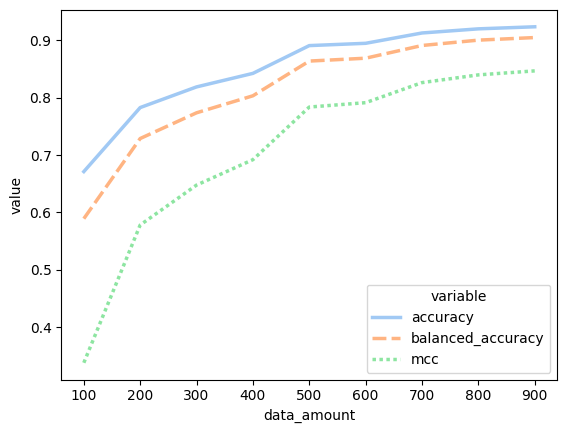

In [63]:
sns.lineplot(data=pd.melt(results_df, ['data_amount']), x='data_amount', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)